# Riesgo clínico para una red de clínicas

In [4]:
# 1. Importar librerias
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

Cargué las herramientas de análisis estadístico (scipy), manejo de datos (pandas) y visualización (matplotlib, seaborn).

In [5]:
# 2. Cargar el dataset
df = pd.read_csv("heart_raw.csv")
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,diagnosis
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Importé los 303 pacientes originales del archivo CSV.

El dataset proviene del UCI Machine Learning Repository (base de datos de Cleveland) y contiene 303 pacientes (filas) con 14 variables (columnas): 13 predictoras (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal) y 1 variable objetivo (diagnosis).

In [6]:
# 3. Revisar valores faltantes
print("Valores unicos en 'ca':", sorted(df["ca"].astype(str).unique()))
print("Valores unicos en 'thal':", sorted(df["thal"].astype(str).unique()))

Valores unicos en 'ca': ['0.0', '1.0', '2.0', '3.0', '?']
Valores unicos en 'thal': ['3.0', '6.0', '7.0', '?']


In [7]:
# 4. Eliminar pacientes con valores faltantes ('?' en ca o thal)
df_clean = df[(df["ca"] != "?") & (df["thal"] != "?")].copy()
df_clean["ca"] = df_clean["ca"].astype(float)
df_clean["thal"] = df_clean["thal"].astype(float)

print(f"Pacientes originales: {len(df)}")
print(f"Pacientes tras limpieza: {len(df_clean)}")
print(f"Eliminados: {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df):.1%})")

Pacientes originales: 303
Pacientes tras limpieza: 297
Eliminados: 6 (2.0%)


Detecté 6 pacientes con datos incompletos, codificados como '?' en las columnas ca y thal.

In [8]:
# 5. Variable objetivo binaria
df_clean["target"] = (df_clean["diagnosis"] > 0).astype(int)

n_total = len(df_clean)
n_pos = df_clean["target"].sum()
n_neg = n_total - n_pos
prior_enfermedad = n_pos / n_total

print(f"Total pacientes: {n_total}")
print(f"Con enfermedad (target=1): {n_pos} ({prior_enfermedad:.3f})")
print(f"Sin enfermedad (target=0): {n_neg} ({1-prior_enfermedad:.3f})")

Total pacientes: 297
Con enfermedad (target=1): 137 (0.461)
Sin enfermedad (target=0): 160 (0.539)


Recodifiqué el diagnóstico original (escala 0-4) a una variable binaria: sano o enfermo, obteniendo el prior poblacional de 46.1%.

In [9]:
# 6. Probabilidad condicional: P(enfermedad | dolor asintomatico)
asintomatico = df_clean[df_clean["cp"] == 4]
p_enf_dado_asintomatico = asintomatico["target"].mean()

print(f"Pacientes con dolor asintomatico (cp=4): {len(asintomatico)}")
print(f"P(enfermedad | dolor asintomatico) = {p_enf_dado_asintomatico:.3f}")
print(f"Prior general = {prior_enfermedad:.3f}")
print(f"Diferencia: +{p_enf_dado_asintomatico - prior_enfermedad:.3f}")

Pacientes con dolor asintomatico (cp=4): 142
P(enfermedad | dolor asintomatico) = 0.725
Prior general = 0.461
Diferencia: +0.264


Calculé cuánto sube la probabilidad de enfermedad cuando el paciente tiene dolor de pecho asintomático (0.725).

In [10]:
# 7. Teorema de Bayes: P(enfermedad | angina inducida)
p_angina_dado_enf = df_clean[df_clean["target"] == 1]["exang"].mean()
p_angina_dado_sano = df_clean[df_clean["target"] == 0]["exang"].mean()
p_angina_total = df_clean["exang"].mean()

# Bayes: P(enf | angina) = P(angina | enf) * P(enf) / P(angina)
p_enf_dado_angina = (p_angina_dado_enf * prior_enfermedad) / p_angina_total

print(f"Prior P(enfermedad) = {prior_enfermedad:.3f}")
print(f"P(angina | enfermedad) = {p_angina_dado_enf:.3f}")
print(f"P(angina | sano) = {p_angina_dado_sano:.3f}")
print(f"P(angina) total = {p_angina_total:.3f}")
print(f"Posterior P(enfermedad | angina) = {p_enf_dado_angina:.3f}")
print(f"Movimiento respecto al prior: {p_enf_dado_angina - prior_enfermedad:+.3f}")

# Verificacion por conteo directo (debe coincidir con Bayes)
verificacion = df_clean[df_clean["exang"] == 1]["target"].mean()
print(f"\nVerificacion por conteo directo: {verificacion:.3f}")

Prior P(enfermedad) = 0.461
P(angina | enfermedad) = 0.540
P(angina | sano) = 0.144
P(angina) total = 0.327
Posterior P(enfermedad | angina) = 0.763
Movimiento respecto al prior: +0.302

Verificacion por conteo directo: 0.763


invertí la probabilidad de "angina dado enfermedad" para obtener "enfermedad dado angina" (0.763), y lo verifiqué contra el conteo directo.

In [11]:
# 8. Verosimilitud / MLE: Gaussiana ajustada al colesterol por clase
chol_enf = df_clean[df_clean["target"] == 1]["chol"]
chol_sano = df_clean[df_clean["target"] == 0]["chol"]

# MLE de una Gaussiana: mu_hat = media muestral, sigma_hat = std muestral
mu_enf, sigma_enf = stats.norm.fit(chol_enf)
mu_sano, sigma_sano = stats.norm.fit(chol_sano)

print("MLE Gaussiana -- Colesterol en pacientes CON enfermedad:")
print(f"  mu_hat = {mu_enf:.2f} mg/dl, sigma_hat = {sigma_enf:.2f}")
print("MLE Gaussiana -- Colesterol en pacientes SIN enfermedad:")
print(f"  mu_hat = {mu_sano:.2f} mg/dl, sigma_hat = {sigma_sano:.2f}")

# Log-verosimilitud de cada ajuste
loglik_enf = np.sum(stats.norm.logpdf(chol_enf, mu_enf, sigma_enf))
loglik_sano = np.sum(stats.norm.logpdf(chol_sano, mu_sano, sigma_sano))
print(f"\nLog-verosimilitud (con enfermedad): {loglik_enf:.2f}")
print(f"Log-verosimilitud (sin enfermedad): {loglik_sano:.2f}")

MLE Gaussiana -- Colesterol en pacientes CON enfermedad:
  mu_hat = 251.85 mg/dl, sigma_hat = 49.50
MLE Gaussiana -- Colesterol en pacientes SIN enfermedad:
  mu_hat = 243.49 mg/dl, sigma_hat = 53.59

Log-verosimilitud (con enfermedad): -728.96
Log-verosimilitud (sin enfermedad): -864.05


Ajusté una distribución Gaussiana al colesterol por separado en cada grupo, para comparar sus parámetros.

In [24]:
# 9. Prior y Posterior: actualizacion bayesiana secuencial
def actualizar_posterior(prior, likelihood_dado_enf, likelihood_dado_sano):
    """Un paso de actualizacion bayesiana."""
    evidencia = likelihood_dado_enf * prior + likelihood_dado_sano * (1 - prior)
    posterior = (likelihood_dado_enf * prior) / evidencia
    return posterior

# Caso de ejemplo: paciente con cp=4 (asintomatico), exang=1 (angina), thal=7 (defecto reversible)
paso0 = prior_enfermedad

# Paso 1: evidencia = dolor asintomatico 
lik_cp4_enf = df_clean[df_clean["target"] == 1]["cp"].apply(lambda x: x == 4).mean()
lik_cp4_sano = df_clean[df_clean["target"] == 0]["cp"].apply(lambda x: x == 4).mean()
paso1 = actualizar_posterior(paso0, lik_cp4_enf, lik_cp4_sano)

# Paso 2: evidencia = angina inducida (exang=1)
lik_exang_enf = p_angina_dado_enf
lik_exang_sano = p_angina_dado_sano
paso2 = actualizar_posterior(paso1, lik_exang_enf, lik_exang_sano)

# Paso 3: evidencia = thal=7 (defecto reversible)
lik_thal7_enf = df_clean[df_clean["target"] == 1]["thal"].apply(lambda x: x == 7).mean()
lik_thal7_sano = df_clean[df_clean["target"] == 0]["thal"].apply(lambda x: x == 7).mean()
paso3 = actualizar_posterior(paso2, lik_thal7_enf, lik_thal7_sano)

print("Actualizacion bayesiana secuencial (orden: cp -> exang -> thal):")
print(f"  Prior inicial:                    {paso0:.3f}")
print(f"  Tras dolor asintomatico (cp=4):    {paso1:.3f}")
print(f"  Tras angina inducida (exang=1):    {paso2:.3f}")
print(f"  Tras defecto reversible (thal=7):  {paso3:.3f}")

Actualizacion bayesiana secuencial (orden: cp -> exang -> thal):
  Prior inicial:                    0.461
  Tras dolor asintomatico (cp=4):    0.725
  Tras angina inducida (exang=1):    0.908
  Tras defecto reversible (thal=7):  0.974


Actualicé secuencialmente la probabilidad de enfermedad con tres pruebas clínicas, llevándola de 46.1% a 97.4%.

In [25]:
# 10. Mismo caso, orden inverso de las pruebas
paso1_b = actualizar_posterior(paso0, lik_thal7_enf, lik_thal7_sano)
paso2_b = actualizar_posterior(paso1_b, lik_exang_enf, lik_exang_sano)
paso3_b = actualizar_posterior(paso2_b, lik_cp4_enf, lik_cp4_sano)

print("Mismo caso, orden INVERSO (thal -> exang -> cp):")
print(f"  Prior inicial:                    {paso0:.3f}")
print(f"  Tras defecto reversible (thal=7):  {paso1_b:.3f}")
print(f"  Tras angina inducida (exang=1):    {paso2_b:.3f}")
print(f"  Tras dolor asintomatico (cp=4):    {paso3_b:.3f}")



Mismo caso, orden INVERSO (thal -> exang -> cp):
  Prior inicial:                    0.461
  Tras defecto reversible (thal=7):  0.765
  Tras angina inducida (exang=1):    0.925
  Tras dolor asintomatico (cp=4):    0.974


Repetí la misma actualización en orden contrario para comprobar que el resultado final no cambia.

In [14]:
# 11. Divergencia KL: colesterol con enfermedad vs sin enfermedad
def kl_divergence_discretizada(muestra_p, muestra_q, bins=15, rango=None):
    """KL(P || Q) discretizando ambas muestras en el mismo conjunto de bins."""
    if rango is None:
        combinado = np.concatenate([muestra_p, muestra_q])
        rango = (combinado.min(), combinado.max())
    hist_p, edges = np.histogram(muestra_p, bins=bins, range=rango, density=False)
    hist_q, _ = np.histogram(muestra_q, bins=bins, range=rango, density=False)

    # Normalizar a probabilidades, con suavizado para evitar log(0)
    eps = 1e-6
    p = (hist_p + eps) / (hist_p.sum() + eps * bins)
    q = (hist_q + eps) / (hist_q.sum() + eps * bins)

    kl = np.sum(p * np.log(p / q))
    return kl

kl_chol = kl_divergence_discretizada(chol_enf.values, chol_sano.values, bins=15)
kl_chol_inversa = kl_divergence_discretizada(chol_sano.values, chol_enf.values, bins=15)

print(f"KL( colesterol_enfermos || colesterol_sanos ) = {kl_chol:.4f} nats")
print(f"KL( colesterol_sanos || colesterol_enfermos ) = {kl_chol_inversa:.4f} nats")

KL( colesterol_enfermos || colesterol_sanos ) = 0.1194 nats
KL( colesterol_sanos || colesterol_enfermos ) = 0.2448 nats


Medí qué tan diferentes son las distribuciones de colesterol entre sanos y enfermos, en ambas direcciones (KL no es simétrica).

In [28]:
# 12. Distribuciones parametricas: sexo, tipo de dolor, colesterol, frec. cardiaca max.

# sexo (binaria) Bernoulli
p_hombre = df_clean["sex"].mean()
print("Sexo:  Bernoulli(p)")
print(f"  p_hat (proporcion de hombres) = {p_hombre:.3f}")
print(f"  n = {len(df_clean)}, hombres = {int(df_clean['sex'].sum())}, mujeres = {len(df_clean)-int(df_clean['sex'].sum())}")

# tipo de dolor de pecho (4 categorias) -> Categorica
probs_cp = df_clean["cp"].value_counts(normalize=True).sort_index()
print("\nTipo de dolor de pecho: Categorica/Multinomial")
etiquetas_cp = {1: "tipica", 2: "atipica", 3: "no anginoso", 4: "asintomatico"}
for k, v in probs_cp.items():
    print(f"  P(cp={int(k)}, {etiquetas_cp[k]}) = {v:.3f}")

# colesterol (continua)  Gaussiana
stat_chol, p_chol = stats.shapiro(df_clean["chol"])
mu_chol_all, sigma_chol_all = stats.norm.fit(df_clean["chol"])
print(f"\nColesterol:  Gaussiana(mu={mu_chol_all:.1f}, sigma={sigma_chol_all:.1f})")
print(f"  Shapiro-Wilk: W={stat_chol:.4f}, p-valor={p_chol:.4f}")

# frecuencia cardiaca maxima (continua) -> Gaussiana
stat_thalach, p_thalach = stats.shapiro(df_clean["thalach"])
mu_thalach_all, sigma_thalach_all = stats.norm.fit(df_clean["thalach"])
print(f"\nFrrecuencia maxima:  Gaussiana(mu={mu_thalach_all:.1f}, sigma={sigma_thalach_all:.1f})")
print(f"  Shapiro-Wilk: W={stat_thalach:.4f}, p-valor={p_thalach:.4f}")

Sexo:  Bernoulli(p)
  p_hat (proporcion de hombres) = 0.677
  n = 297, hombres = 201, mujeres = 96

Tipo de dolor de pecho: Categorica/Multinomial
  P(cp=1, tipica) = 0.077
  P(cp=2, atipica) = 0.165
  P(cp=3, no anginoso) = 0.279
  P(cp=4, asintomatico) = 0.478

Colesterol:  Gaussiana(mu=247.4, sigma=51.9)
  Shapiro-Wilk: W=0.9483, p-valor=0.0000

Frrecuencia maxima:  Gaussiana(mu=149.6, sigma=22.9)
  Shapiro-Wilk: W=0.9766, p-valor=0.0001


Justifiqué qué tipo de distribución (Bernoulli, categórica o Gaussiana) le corresponde a cuatro variables del dataset.

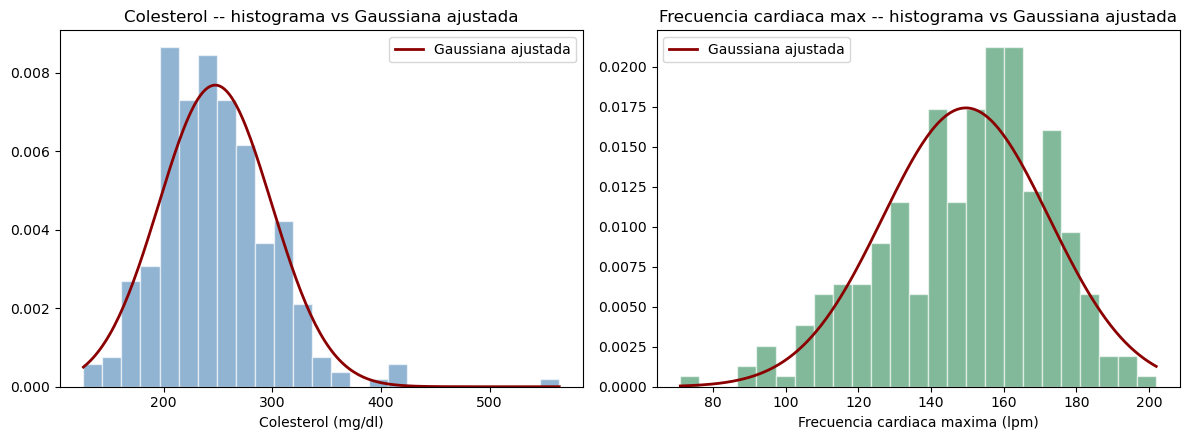

In [16]:
# 13. Histogramas con curva Gaussiana ajustada -- colesterol y frec. cardiaca max.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Colesterol
axes[0].hist(df_clean["chol"], bins=25, density=True, alpha=0.6, color="steelblue", edgecolor="white")
x_chol = np.linspace(df_clean["chol"].min(), df_clean["chol"].max(), 200)
axes[0].plot(x_chol, stats.norm.pdf(x_chol, mu_chol_all, sigma_chol_all), color="darkred", linewidth=2, label="Gaussiana ajustada")
axes[0].set_title("Colesterol -- histograma vs Gaussiana ajustada")
axes[0].set_xlabel("Colesterol (mg/dl)")
axes[0].legend()

# Frecuencia cardiaca maxima
axes[1].hist(df_clean["thalach"], bins=25, density=True, alpha=0.6, color="seagreen", edgecolor="white")
x_thalach = np.linspace(df_clean["thalach"].min(), df_clean["thalach"].max(), 200)
axes[1].plot(x_thalach, stats.norm.pdf(x_thalach, mu_thalach_all, sigma_thalach_all), color="darkred", linewidth=2, label="Gaussiana ajustada")
axes[1].set_title("Frecuencia cardiaca max -- histograma vs Gaussiana ajustada")
axes[1].set_xlabel("Frecuencia cardiaca maxima (lpm)")
axes[1].legend()

plt.tight_layout()
plt.show()

Visualicé qué tan bien se ajusta la Gaussiana estimada al colesterol y a la frecuencia cardíaca real.

In [17]:
# 14. Esperanza y Varianza: frecuencia cardiaca maxima, por presencia/ausencia de enfermedad
thalach_enf = df_clean[df_clean["target"] == 1]["thalach"]
thalach_sano = df_clean[df_clean["target"] == 0]["thalach"]

print("Frecuencia cardiaca maxima -- CON enfermedad:")
print(f"  Esperanza (media) = {thalach_enf.mean():.2f} lpm")
print(f"  Varianza = {thalach_enf.var():.2f}")
print("Frecuencia cardiaca maxima -- SIN enfermedad:")
print(f"  Esperanza (media) = {thalach_sano.mean():.2f} lpm")
print(f"  Varianza = {thalach_sano.var():.2f}")
print(f"\nDiferencia de medias: {thalach_sano.mean() - thalach_enf.mean():.2f} lpm")

Frecuencia cardiaca maxima -- CON enfermedad:
  Esperanza (media) = 139.11 lpm
  Varianza = 515.77
Frecuencia cardiaca maxima -- SIN enfermedad:
  Esperanza (media) = 158.58 lpm
  Varianza = 362.65

Diferencia de medias: 19.47 lpm


Comparé el promedio y la dispersión de la frecuencia cardíaca máxima entre pacientes sanos y enfermos.

Tabla de contingencia (sexo vs enfermedad):
target   0    1
sex            
0       71   25
1       89  112

Chi2 = 21.852, p-valor = 0.00000
Se rechaza independencia (p<0.05)

Matriz de correlacion:
           age  trestbps  chol  thalach  oldpeak
age       1.00      0.29  0.20    -0.39     0.20
trestbps  0.29      1.00  0.13    -0.05     0.19
chol      0.20      0.13  1.00    -0.00     0.04
thalach  -0.39     -0.05 -0.00     1.00    -0.35
oldpeak   0.20      0.19  0.04    -0.35     1.00


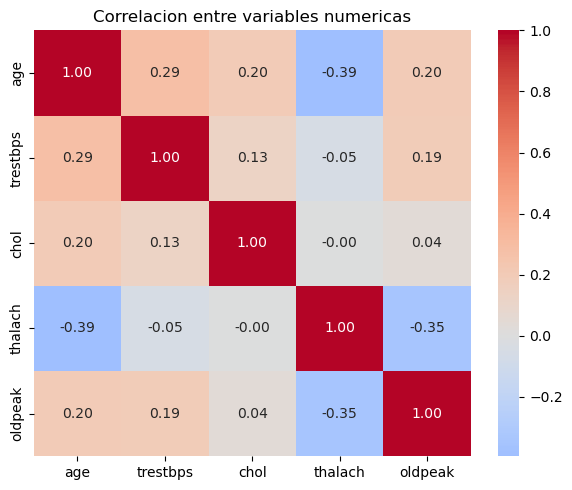

In [18]:
# 15. Independencia y Correlacion
# Tabla de contingencia: sexo vs enfermedad + test chi-cuadrado
tabla_cont = pd.crosstab(df_clean["sex"], df_clean["target"])
chi2, p_valor, dof, esperado = stats.chi2_contingency(tabla_cont)
print("Tabla de contingencia (sexo vs enfermedad):")
print(tabla_cont)
print(f"\nChi2 = {chi2:.3f}, p-valor = {p_valor:.5f}")
print(f"{'Se rechaza independencia (p<0.05)' if p_valor < 0.05 else 'No se rechaza independencia'}")

# Matriz de correlacion entre variables numericas
vars_numericas = ["age", "trestbps", "chol", "thalach", "oldpeak"]
corr_matrix = df_clean[vars_numericas].corr()
print("\nMatriz de correlacion:")
print(corr_matrix.round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlacion entre variables numericas")
plt.tight_layout()
plt.show()

Probé si el sexo y la enfermedad están relacionados (sí lo están), y calculé la correlación entre las variables numéricas.

In [19]:
# 16. Entropia: H(target) vs H(target | cp)
def entropia(probs):
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

# Entropia de la variable objetivo
p_target = df_clean["target"].value_counts(normalize=True)
H_target = entropia(p_target.values)
print(f"Entropia H(target) = {H_target:.4f} bits")

# Entropia condicional H(target | cp)
H_cond = 0
for cp_val in df_clean["cp"].unique():
    subset = df_clean[df_clean["cp"] == cp_val]
    p_subset = len(subset) / len(df_clean)
    p_target_dado_cp = subset["target"].value_counts(normalize=True)
    H_cond += p_subset * entropia(p_target_dado_cp.values)

print(f"Entropia condicional H(target | cp) = {H_cond:.4f} bits")
print(f"Reduccion de incertidumbre (informacion mutua) = {H_target - H_cond:.4f} bits")

Entropia H(target) = 0.9957 bits
Entropia condicional H(target | cp) = 0.7985 bits
Reduccion de incertidumbre (informacion mutua) = 0.1972 bits


In [ ]:
Medí cuánta incertidumbre sobre el diagnóstico se reduce al conocer el tipo de dolor de pecho.

In [20]:
# 17. Entropia cruzada: clasificador logistico
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

features = ["age", "sex", "cp", "trestbps", "chol", "thalach", "exang", "oldpeak"]
X = df_clean[features]
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

proba_train = modelo.predict_proba(X_train)
proba_test = modelo.predict_proba(X_test)

ce_train = log_loss(y_train, proba_train)
ce_test = log_loss(y_test, proba_test)

print(f"Entropia cruzada (entrenamiento) = {ce_train:.4f}")
print(f"Entropia cruzada (prueba) = {ce_test:.4f}")
print(f"Accuracy en prueba = {modelo.score(X_test, y_test):.3f}")

Entropia cruzada (entrenamiento) = 0.4447
Entropia cruzada (prueba) = 0.3839
Accuracy en prueba = 0.813


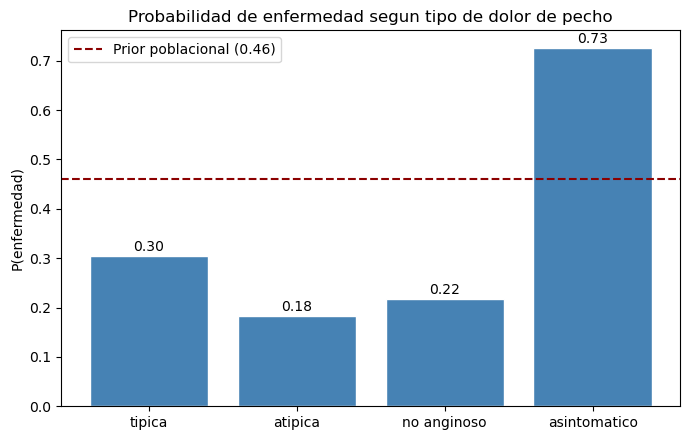

In [21]:
# Grafico: probabilidad de enfermedad por tipo de dolor de pecho
p_enf_por_cp = df_clean.groupby("cp")["target"].mean()
etiquetas_cp = {1: "tipica", 2: "atipica", 3: "no anginoso", 4: "asintomatico"}
nombres = [etiquetas_cp[i] for i in p_enf_por_cp.index]

plt.figure(figsize=(7, 4.5))
barras = plt.bar(nombres, p_enf_por_cp.values, color="steelblue", edgecolor="white")
plt.axhline(prior_enfermedad, color="darkred", linestyle="--", linewidth=1.5, label=f"Prior poblacional ({prior_enfermedad:.2f})")
plt.ylabel("P(enfermedad)")
plt.title("Probabilidad de enfermedad segun tipo de dolor de pecho")
plt.legend()
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.01, f"{altura:.2f}", ha="center")
plt.tight_layout()
plt.show()

El dolor de pecho asintomático muestra la mayor probabilidad de enfermedad (0.72), muy por encima del prior poblacional (0.46), mientras que el dolor típico es el que menos se asocia con enfermedad (0.20).

C:\Users\Asus\AppData\Local\Temp\ipykernel_20944\3651863327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="thalach", data=df_clean, palette=["seagreen", "indianred"])


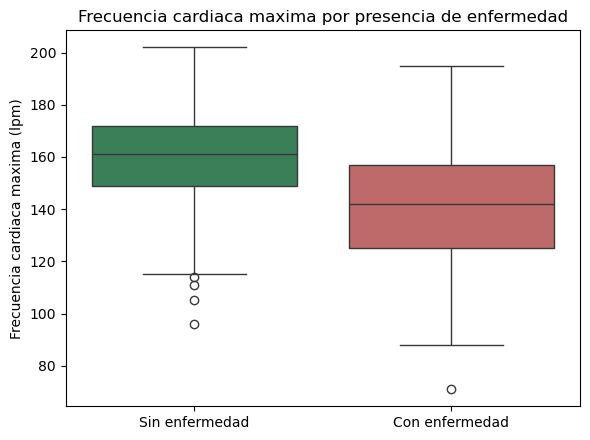

In [22]:
# Grafico: frecuencia cardiaca maxima segun presencia de enfermedad
plt.figure(figsize=(6, 4.5))
sns.boxplot(x="target", y="thalach", data=df_clean, palette=["seagreen", "indianred"])
plt.xticks([0, 1], ["Sin enfermedad", "Con enfermedad"])
plt.ylabel("Frecuencia cardiaca maxima (lpm)")
plt.xlabel("")
plt.title("Frecuencia cardiaca maxima por presencia de enfermedad")
plt.tight_layout()
plt.show()

Los pacientes sin enfermedad tienen una frecuencia cardíaca máxima notablemente más alta (mediana cercana a 160 lpm) que los pacientes con enfermedad (mediana cercana a 140 lpm), con poca superposición entre ambas cajas.

## Conclusiones

- La prevalencia de enfermedad en la muestra es 46.1%. El dolor de pecho asintomático y la angina inducida por ejercicio elevan bastante esa probabilidad (a 72.5% y 76.3%), mientras que el colesterol por sí solo casi no distingue entre pacientes sanos y enfermos: las medias son parecidas (251.9 vs 243.5) y la divergencia KL entre ambas distribuciones es baja.

- La actualización bayesiana secuencial con tres pruebas (dolor de pecho, angina, resultado de talio) lleva el posterior de 46.1% a 97.4%. El orden en que se evalúan las pruebas no cambia el resultado final, siempre que se asuma que son condicionalmente independientes dado el diagnóstico.

- La frecuencia cardíaca máxima sí diferencia bien a los dos grupos: los pacientes con enfermedad alcanzan en promedio 139.1 lpm frente a 158.6 lpm en los sanos.

- El sexo y la presencia de enfermedad no son independientes (chi2=21.85, p<0.001); la proporción de hombres con enfermedad es notablemente mayor que la de mujeres.

- El tipo de dolor de pecho reduce la incertidumbre sobre el diagnóstico: la entropía de la variable objetivo baja de 0.996 a 0.799 bits al condicionar sobre esta variable.

- Un clasificador de regresión logística con las variables clínicas disponibles alcanza 81.3% de exactitud en el conjunto de prueba, con una entropía cruzada de 0.384.